# Day 2 — Cross-Validation

Cross-validating a logistic regression pipeline on the Breast Cancer Wisconsin dataset with cross_val_score, and comparing it to a single train/test split .

## Loading and Preparing the Dataset
Load the dataset, inspect its shape and structure, and check the class balance before splitting.

In [3]:
import pandas as pd 
import numpy as np

from sklearn.metrics import accuracy_score 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns 


In [3]:
df = pd.read_csv("breast-cancer.csv")
print (df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


The dataset has 569 rows and 32 columns — a patient id, the diagnosis label, and 30 numeric measurements.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

.info() confirms all 569 rows are complete across every column.

In [5]:
df["diagnosis"].value_counts()


diagnosis
B    357
M    212
Name: count, dtype: int64

diagnosis has 357 benign (B) and 212 malignant (M) cases .

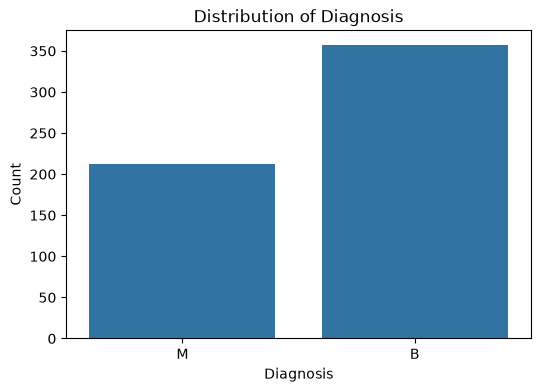

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="diagnosis")

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")

plt.show()

The count plot shows the same imbalance visually — noticeably more benign than malignant cases.

In [7]:
df["diagnosis"] = df["diagnosis"].map({
    "B" : 0,
    "M" : 1
})

diagnosis is mapped to numeric (B → 0, M → 1).

In [8]:
X = df.drop(["diagnosis" , "id"] , axis = 1)
y = df["diagnosis"]

The data is separated into features X (dropping diagnosis and id) and target y (diagnosis).

In [9]:
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =42 , 
    stratify=y
)

An 80/20 train/test split is performed with random_state=42 fixed and stratify=y, so the class balance is preserved in both the training and test sets from the start.

## Baseline — A Single Train/Test Split
Build a Pipeline combining StandardScaler and LogisticRegression, fit it once on the training set, and score it once on the test set — the Day 1-style single-split.

In [10]:
model = Pipeline([
    ("scaler" , StandardScaler()),
    ("classifier" , LogisticRegression(max_iter = 1000))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test ,y_pred)
f1 = f1_score(y_test ,y_pred)
print("Single-Split Accuracy:", accuracy)
print("Single-Split F1:", f1)

Single-Split Accuracy: 0.9649122807017544
Single-Split F1: 0.9512195121951219


**Single-Split Accuracy ≈ 96.5%, F1 ≈ 0.9512.** Bundling the scaler and the classifier into one Pipeline also means that in every cross-validation fold below, the scaler will automatically be fit on that fold's training portion only — no manual risk of leakage.

## Step 1 — 5-Fold Cross-Validation with cross_val_score
Evaluate the same pipeline with 5-fold cross-validation on the training set, scoring by F1.

In [11]:
score = cross_val_score(
    model , 
    X_train,
    y_train ,
    cv = 5,
    scoring = "f1"
)
print("F1 score for each fold:" , score)
mean_f1 = score.mean()
print ("mean f1 score : ", mean_f1)

std_f1 = score.std()
print ("stander devision : ", std_f1)

F1 score for each fold: [0.95384615 0.98550725 0.9375     0.97058824 0.95652174]
mean f1 score :  0.9607926749295036
stander devision :  0.016222248905830575


**Fold-by-fold F1 scores:** 0.954, 0.986, 0.938, 0.971, 0.957 — five different, independent estimates of the model's F1 score, each computed on a different 20% slice of the training data held out in turn.

## Step 2 — Mean and Standard Deviation Across Folds
Summarize the five fold scores with their mean and standard deviation.

In [12]:
print(f"Cross-Validation F1: {mean_f1:.4f} ± {std_f1:.4f}")

Cross-Validation F1: 0.9608 ± 0.0162


**Cross-Validation F1: 0.9608 ± 0.0162.** The mean (0.961) is the reliable performance estimate, and the low standard deviation (0.016) says that estimate is stable — the model performs consistently well no matter which slice of the training data it's evaluated on.

## Step 3 — Comparing to the Single-Split Score

**5-Fold CV F1 (0.9608) vs. Single-Split F1 (0.9512):** the cross-validated average is a bit higher and, more importantly, far more trustworthy — the single-split score is just one sample from roughly the same range the 5 individual folds span (0.938 to 0.986), so it could easily have landed higher or lower depending on which 20% of rows happened to be held out. A full side-by-side comparison table follows further below once the stratified results are also in.

## Step 4 — Confirming Stratified Folds
Explicitly build a StratifiedKFold and re-run cross-validation with it, to confirm class balance is being preserved in every fold.

In [13]:
skf = StratifiedKFold(
    n_splits =5,
    shuffle =True ,
    random_state =42
)

A StratifiedKFold is configured with 5 splits, shuffling enabled, and a fixed random_state for reproducibility.

In [14]:
stratified_score = cross_val_score(
    model,
    X_train,
    y_train,
    cv=skf,
    scoring = "f1"
)

print("Stratified fold score : " ,stratified_score)

Stratified fold score :  [0.9375     0.95652174 1.         0.96969697 0.95652174]


**Stratified fold scores:** 0.938, 0.957, 1.000, 0.970, 0.957 — broadly similar to the plain cv=5 scores from Step 1, which makes sense: Scikit-learn already uses stratified folds by default whenever cross_val_score is passed an integer cv and a classifier, so Step 1 was *already* stratified. The small differences here come from this explicit StratifiedKFold also shuffling the data (shuffle=True) before splitting, which the plain integer cv=5 does not do by default — that's why the fold-by-fold numbers shift slightly even though both are stratified.

In [15]:
stratified_mean = stratified_score.mean()
stratified_std = stratified_score.std()
print(f"tratified CV  F1:{stratified_mean:.4f} ± {stratified_std:.4f}")

tratified CV  F1:0.9640 ± 0.0207


**Stratified CV F1: 0.9640 ± 0.0207** — essentially in line with the plain 5-fold result, confirming that stratification alone wasn't the missing ingredient here; both approaches already preserved class balance.

**Why stratification matters for this dataset:** with 357 benign vs 212 malignant cases (about 63%/37%), an unlucky *non*-stratified split could easily land a fold with, say, only 10% malignant cases — making that fold's F1 score unreliable simply because there wasn't enough of the minority class to learn or evaluate from properly. Preserving the same ~63%/37% ratio in every fold means each of the 5 F1 scores is measuring the same kind of problem, making the mean and standard deviation genuinely comparable and trustworthy — exactly the class-imbalance concern raised back in Week 3.

Collect all three estimates — single split, 5-fold CV, and stratified 5-fold CV — into one comparison table.

In [16]:
comparison = pd.DataFrame({
    "Method":[
        "Single Split ",
        "5_fold cross validation",
        "Stratified 5_fold"
    ],

    "Mean F1" :[
        f1,
        score.mean(),
        stratified_score.mean()
    ],

    "Std":[
        np.nan,
        score.std(),
        stratified_score.std()
    ]
})

comparison

,Method,Mean F1,Std
0,Single Split,0.951220,NaN
1,5_fold cross validation,0.960793,0.016222
2,Stratified 5_fold,0.964048,0.020700


**Full comparison:** Single Split F1 = 0.9512, 5-Fold CV F1 = 0.9608 (± 0.0162), Stratified 5-Fold F1 = 0.9640 (± 0.0207). Cross-validation — stratified or not — gives both a slightly higher and a far more stable estimate than trusting the single split alone.

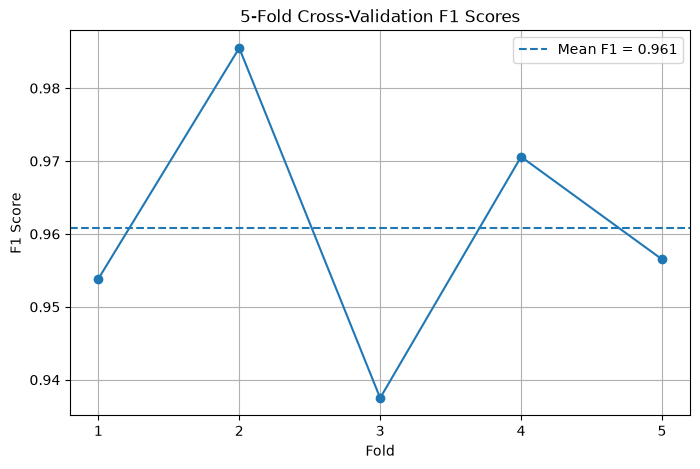

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    score,
    marker="o"
)

plt.axhline(
    score.mean(),
    linestyle="--",
    label=f"Mean F1 = {score.mean():.3f}"
)

plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("5-Fold Cross-Validation F1 Scores")
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True)

plt.show()

The plot visualizes the 5 fold scores from Step 1 as points around their mean (dashed line), making it easy to see at a glance how tightly the folds cluster — all five land within about 5 points of 0.96, visually confirming the low standard deviation reported above.